# Building a Custom LLM with nanoGPT
**Class 4 | From Zero to AI Agents | Fall 26**

Train from scratch using **Karpathy's actual nanoGPT transformer** in PyTorch.
Our classroom tokenizer uses **whole words and punctuation**. nanoGPT does not
dictate tokenization: its examples include characters and GPT-2 subwords. Word
tokens are our teaching choice, not a new architecture or pretrained embeddings.
Your job is to choose, predict, run, inspect, and explain, not implement the network.
A small model on a narrow corpus is not a chat assistant or a general map of meaning.

[Assignment](https://docs.google.com/document/d/1MQ3YQl2ywWZF7W5_l_91FiIp7pTYPO_3viI2JVapRcc/edit)
| [Sample project](https://github.com/pepealonso95/custom-llm)
| [nanoGPT source](https://github.com/karpathy/nanoGPT)

## How Evals Affect Your Assignment Grade

This assignment is graded out of 10 using the course framework: deliverable quality (4 points), testing & evaluation (3 points), and working result (3 points). The 48-case eval percentage is a model measurement, not your assignment grade. The runner does not calculate your grade.

- Deliverable quality (4 points): submit both executed experiments, readable source code, corpus sources and choices, and a clear README. Explain the model's learning process using your actual token, embedding, gradient, and loss evidence. Explain why you chose at least two extension categories and how your new teaching material addresses their gaps.

- Testing & evaluation (3 points): run all 48 unchanged cases before and after training in each experiment. That means four complete result sets: starter untrained, starter trained, expanded-corpus untrained, and expanded-corpus trained. Save every case, the CSV/JSON results, summaries, and separation checks. Compare all-case success, scorable accuracy, vocabulary coverage, group/category scores, and actual free continuations, alongside the existing loss evidence. Explain failures and whether changes reflect vocabulary coverage, learned patterns, or both.

- Working result (3 points): demonstrate your trained nanoGPT, rerunnable evals on your saved model, and a working interface that produces actual replies from that model. Include launch instructions, the model/run identity, and at least 3 real chat interactions with a screenshot or recording. A terminal or notebook interface is sufficient; a polished website is not required.

Running and interpreting the evals is required. Missing runs, omitted cases, a missing corpus-extension comparison, or unsupported conclusions reduce testing & evaluation credit. Results produced by training on test prompts or answer keys are not valid evaluation evidence; remove the leakage and rerun. Incomplete notebook/code or a nonworking model/interface also affects the relevant deliverable or working-result category. Partial credit follows the evidence provided; this is not an automatic all-or-nothing checklist.

There is no minimum model pass rate, leaderboard, or required numerical improvement. A low score, unknown-word cases, or an extension experiment that does not improve can still earn full testing & evaluation credit when the required experiments are complete, the method is valid, and the analysis explains what happened. Unknown-word cases count as zero in the model's all-case metric, not as an automatic deduction of the same percentage from your grade. A high score alone cannot replace valid evaluation, understanding, and a working deliverable.

Before submitting, make the README show a four-row comparison for the two experiments and their untrained/trained stages, link all four result sets, identify the extension categories and added data, discuss at least one concrete failure or limitation, and link your chat evidence.

## 1. Make three choices
**Corpus:** put PDF, TXT or Markdown files in `corpus/` to expand the supplied
classroom sentences. Set CORPUS="folder" to use only your files instead.
**Training steps:** 10 checks setup; start with 3,000 for the experiment. One step
updates weights using 32 documents, not the entire corpus. Try 5,000 or 10,000 later
if useful, but compare validation loss rather than assuming more is better.
**Learning rate:** start at 0.001, with warmup and cosine decay in the training cell.
Write your reasons and prediction before running. AI assistants helping a student
should ask for these choices before training and explain actual outputs.

In [1]:
CORPUS = "classroom"       # Teaching sentences + files; "folder" uses only files
CORPUS_FOLDER = "corpus"   # Add .pdf, .txt and .md files here, including subfolders
TRAINING_STEPS = 5000      # 10 for setup; 5000 for the main experiment
LEARNING_RATE = 0.001


### My prediction

**Experiment 2 — starter corpus + negation + spatial-relations extension.**
CORPUS="classroom" (same base sentences) plus `corpus/negation.txt` (40 sentences,
correction pattern "X did not VERB OBJ1 . X VERB-ed OBJ2 . X VERB-ed" plus state
corrections "the NOUN is not ADJ1 . it is ADJ2 . the NOUN is ADJ2") and
`corpus/spatial_relations.txt` (49 sentences covering above/below, left/right,
inside/contains, in front of/behind, and between/next-to, each stated and then
restated with the inverse relation). Same 5,000 steps and learning rate 0.001 as
Experiment 1, so any eval differences should trace to the added data, not the
training budget.

I expect the same overall shape of loss curve and starter-domain behavior as
Experiment 1. The new prediction is that the `negation` and `spatial_relations`
categories in `extend_corpus` should score measurably better than Experiment 1's
near-zero, since the exact vocabulary ("not", "never", "above", "below", "inside",
"contains", "left", "right", "between") and sentence shapes now appear in training —
though I don't expect a clean sweep, since 89 new passages is small next to the
509-token vocabulary cap, and only 90% of them enter training after the split. I do
*not* expect gains on the other six `extend_corpus` categories (grammar, opposites,
reference, sequence, everyday_knowledge, categories_and_analogies), since I added no
data for those — cases that were `out_of_vocabulary` in Experiment 1 should mostly stay
that way here. I also expect the training-vocabulary unknown-token rate to shift
slightly, since the new passages introduce words that compete for the fixed 509
most-frequent-token slots, which could push out a few of the rarer classroom words.


In [2]:
import csv
import hashlib
import importlib.util
import json
import math
import platform
import random
import re
import shutil
import subprocess
import sys
import time
import urllib.request
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path
import torch
from torch.nn import functional as F

# A saved Colab notebook needs its companion files; opening from GitHub does not
# copy them. This release pins their content, independently of model weights.
SUPPORT_REF = "f83578ff4fa4d8f582c7ac29a9276ef4a7bc13e8"
SUPPORT_FILES = {'run_evals.py': 'da87f28d128344807512e2bac1cfc662b37ac2c7e4a32b84c09f1950e92d67a0', 'chat.py': '6152c8b7780f3b46fef5de38461adfc4b1a55df70ed106ca73ec5e9aded86d25', 'evals/language_evals.json': 'e8affcd72841e3ed7da5c0b6b116327fe9f69c9abd66a1180d1d88ceaa3e17f7'}  # Exact support-file SHA-256 checksums.
for relative, expected_hash in SUPPORT_FILES.items():
    destination = Path(relative)
    if not destination.exists():
        url = f"https://raw.githubusercontent.com/pepealonso95/custom-llm/{SUPPORT_REF}/{relative}"
        with urllib.request.urlopen(url, timeout=30) as response:
            data = response.read()
        if hashlib.sha256(data).hexdigest() != expected_hash:
            raise ValueError(f"Downloaded {relative} failed its hash check.")
        destination.parent.mkdir(parents=True, exist_ok=True)
        destination.write_bytes(data)
    if hashlib.sha256(destination.read_bytes()).hexdigest() != expected_hash:
        raise ValueError(f"{relative} differs from this notebook's fixed version. Restore it or reopen the latest starter.")
from run_evals import (load_suite, evaluate_suite, generate_reply, model_hash,
                       reject_eval_leakage, reserve_classroom_passages, validate_corpus_location)
language_suite = load_suite("evals/language_evals.json")
validate_corpus_location(CORPUS_FOLDER, "evals/language_evals.json")

if importlib.util.find_spec("pypdf") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pypdf>=5,<7"])
Path(CORPUS_FOLDER).mkdir(parents=True, exist_ok=True)

if isinstance(TRAINING_STEPS, bool) or not isinstance(TRAINING_STEPS, int) or TRAINING_STEPS < 1:
    raise ValueError("TRAINING_STEPS must be a positive whole number.")
if isinstance(LEARNING_RATE, bool) or not isinstance(LEARNING_RATE, (int, float)) or not math.isfinite(LEARNING_RATE) or LEARNING_RATE <= 0:
    raise ValueError("LEARNING_RATE must be finite and positive.")
UPSTREAM_COMMIT = "3adf61e154c3fe3fca428ad6bc3818b27a3b8291"
UPSTREAM_SHA256 = "7c01703240dbec5d554527dc666e35b3df8391d0b117fddc07afcf325a21d11c"
model_file = Path("nanogpt_model.py")
if not model_file.exists():
    with urllib.request.urlopen(f"https://raw.githubusercontent.com/karpathy/nanoGPT/{UPSTREAM_COMMIT}/model.py", timeout=30) as response:
        source = response.read()
    if hashlib.sha256(source).hexdigest() != UPSTREAM_SHA256:
        raise ValueError("Downloaded nanoGPT source failed its hash check.")
    model_file.write_bytes(source)
if hashlib.sha256(model_file.read_bytes()).hexdigest() != UPSTREAM_SHA256:
    raise ValueError("nanoGPT source differs from the pinned version. Restore the supplied file.")
spec = importlib.util.spec_from_file_location("classroom_nanogpt", model_file)
nanogpt = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = nanogpt
spec.loader.exec_module(nanogpt)
SEED, N_EMBD, N_HEAD, N_LAYER, BLOCK_SIZE, BATCH_SIZE = 42, 64, 4, 2, 48, 32
DEVICE = "cpu"  # Optional: "cuda" on a Colab GPU, or "mps" on Apple Silicon
torch.set_num_threads(min(4, torch.get_num_threads()))
torch.manual_seed(SEED)
print("PyTorch:", torch.__version__, "| device:", DEVICE)

PyTorch: 2.8.0 | device: cpu


## 3. Meet the corpus
A **corpus** is a collection of examples. The default generator creates sentences
about business, food, transport, technology, health, and education. Related nouns
deliberately share contexts. **No category labels or coordinates go into the model
or viewer.** The model receives only sentence text for next-token prediction.
This is a controlled demonstration, not evidence of broad semantic understanding.

We deduplicate normalized documents and hold out 10% before building the vocabulary.
Validation contains new sentences from the SAME templates, not new domains/templates.
Add PDFs with selectable text, UTF-8 TXT, or Markdown to corpus/. The default adds
their text to these sentences; "folder" uses only files and requires 100 passages.
Long text is split into non-overlapping passages of at most 47 tokens, not truncated.
Markdown is plain text; links/code are never fetched or executed. Scans need OCR first.
Inspect corpus_manifest.json for file previews, counts and extraction warnings.
The random split is by unique passage, not source file: passages from the same file
can appear in both sets. This does not test generalization to unseen documents.
Adding files requires Run All to retrain; it is not retrieval or instant knowledge.
Files in corpus/ are Git-ignored, but the results ZIP includes extracted text.
Before splitting, the starter removes sentences containing reserved eval prompts.
Imported files containing exact test prompts are rejected. This checks normalized
text matches, not meaning: you must still avoid copying answer keys or test paraphrases.

In [3]:
def word_tokens(text):
    return re.findall(r"\w+(?:['’]\w+)*|[^\w\s]", text.lower(), flags=re.UNICODE)

def chunk_text(text, max_tokens=47):
    """Keep sentence/line boundaries when possible; split long units without overlap."""
    chunks = []
    for unit in re.split(r"(?<=[.!?])\s+|\n+", text):
        tokens = word_tokens(unit)
        chunks.extend(" ".join(tokens[i:i+max_tokens]) for i in range(0, len(tokens), max_tokens))
    return chunks

def load_corpus_folder(folder, max_tokens=47):
    """Read only local, supported regular files. Never fetch document links or do OCR."""
    from pypdf import PdfReader
    validate_corpus_location(folder, "evals/language_evals.json")
    root = Path(folder).resolve()
    if not root.is_dir():
        raise ValueError(f"Corpus folder not found: {root}. Create it and add PDF, TXT or MD files.")
    chunks, records, ignored = [], [], []
    paths = []
    for path in sorted(root.rglob("*")):
        relative = path.relative_to(root)
        if any(part.startswith(".") for part in relative.parts) or path == root/"README.md":
            continue
        if any(root.joinpath(*relative.parts[:i]).is_symlink() for i in range(1, len(relative.parts)+1)):
            ignored.append({"file":str(relative), "reason":"symbolic link"})
            continue
        if not path.is_file():
            continue
        if path.suffix.lower() not in {".pdf", ".txt", ".md"}:
            ignored.append({"file":str(relative), "reason":"unsupported extension"})
            continue
        paths.append(path)
    if len(paths) > 50 or sum(p.stat().st_size for p in paths) > 100*1024*1024:
        raise ValueError("Use at most 50 supported corpus files and 100 MB total.")
    for path in paths:
        relative = str(path.relative_to(root))
        size = path.stat().st_size
        if size > 25*1024*1024:
            raise ValueError(f"{relative}: exceeds the classroom limit of 25 MB per file.")
        data = path.read_bytes()
        record = {"file":relative, "bytes":size, "sha256":hashlib.sha256(data).hexdigest(), "warnings":[]}
        try:
            if path.suffix.lower() == ".pdf":
                import io
                reader = PdfReader(io.BytesIO(data))
                if reader.is_encrypted:
                    raise ValueError("encrypted PDF; export an unlocked copy you are allowed to use")
                if len(reader.pages) > 200:
                    raise ValueError("PDF exceeds 200 pages; use a smaller excerpt")
                pages = []
                record["pages"] = len(reader.pages)
                for number, page in enumerate(reader.pages, 1):
                    page_text = page.extract_text() or ""
                    if not page_text.strip():
                        record["warnings"].append(f"Page {number}: no text extracted (blank or scanned); OCR may be needed.")
                    pages.append(page_text)
                    if sum(map(len, pages)) > 2_000_000:
                        raise ValueError("extracted text exceeds 2 million characters")
                text = "\n".join(pages)
            else:
                text = data.decode("utf-8-sig")
            if not any(character.isalnum() for character in text):
                raise ValueError("no readable text; empty files and image-only PDFs cannot train this model. Run OCR on scans first")
            if len(text) > 2_000_000:
                raise ValueError("text exceeds 2 million characters")
            reject_eval_leakage(text, language_suite, relative)
            file_chunks = chunk_text(text, max_tokens)
        except Exception as exc:
            raise ValueError(f"Could not import {relative}: {exc}") from exc
        record.update({"characters":len(text), "passages":len(file_chunks), "unique_passages":len(set(file_chunks)), "preview":text[:300]})
        records.append(record)
        chunks.extend(file_chunks)
    return chunks, {"files":records, "ignored":ignored, "external_passages":len(chunks)}

def classroom_corpus():
    domains = [
        ("customer client buyer shopper consumer subscriber", "service purchase support order", "store"),
        ("product item package brand merchandise offering", "price quality delivery design", "market"),
        ("loan credit mortgage investment bond deposit", "interest risk payment return", "bank"),
        ("apple banana orange pear peach mango", "fruit taste juice harvest", "kitchen"),
        ("car bus train truck taxi bicycle", "travel route traffic journey", "station"),
        ("software application program platform website system", "code data security update", "office"),
        ("doctor nurse physician surgeon therapist dentist", "patient health care treatment", "hospital"),
        ("teacher tutor instructor professor educator lecturer", "student lesson course learning", "school"),
    ]
    sentences = []
    for nouns, contexts, place in domains:
        for noun in nouns.split():
            for context in contexts.split():
                for adjective in ["new", "local", "important", "different"]:
                    for frame in [
                        "the team discussed the {noun} and the {context} at the {place} .",
                        "we learned about the {adjective} {noun} during a discussion of {context} .",
                        "the report about the {noun} explains the {context} in detail .",
                        "our {place} has a question about the {adjective} {noun} and {context} .",
                        "they compared the {adjective} {noun} with another {noun} at the {place} .",
                        "a review of {context} helped us understand the {adjective} {noun} .",
                        "today the {place} focused on {context} and the {adjective} {noun} .",
                        "the {adjective} {noun} was mentioned in the {context} report yesterday .",
                    ]:
                        sentences.append(frame.format(noun=noun, context=context, place=place, adjective=adjective))
    for noun in "customer client buyer shopper consumer subscriber".split():
        for product in "product item package brand merchandise offering".split():
            for verb in "ordered reviewed compared returned recommended selected".split():
                sentences.append(f"the {noun} {verb} the {product} after checking the price .")
    return "\n".join(sentences)

extra_chunks, corpus_manifest = load_corpus_folder(CORPUS_FOLDER, BLOCK_SIZE-1)
if CORPUS == "classroom":
    base_text = classroom_corpus()
    corpus_source = "Synthetic classroom sentences plus corpus folder files"
elif CORPUS == "folder":
    if not corpus_manifest["files"]:
        raise ValueError("CORPUS='folder' needs PDF, TXT or MD files in CORPUS_FOLDER. No readable files were found.")
    base_text = ""
    corpus_source = "Corpus folder files only"
else:
    base_text = Path(CORPUS).read_text(encoding="utf-8-sig")
    reject_eval_leakage(base_text, language_suite, CORPUS)
    corpus_source = "Custom UTF-8 base file plus corpus folder files"
base_chunks = chunk_text(base_text, BLOCK_SIZE-1)
base_chunks, eval_separation = reserve_classroom_passages(base_chunks, language_suite)
all_chunks = base_chunks + extra_chunks
for passage in all_chunks:
    reject_eval_leakage(passage, language_suite, "final corpus passage")
raw_text = "\n".join(all_chunks)
docs = sorted(set(all_chunks))
corpus_manifest.update({"mode":CORPUS, "base_passages":len(base_chunks), "unique_passages":len(docs),
    "new_unique_passages":len(set(extra_chunks)-set(base_chunks)), "duplicates_removed":len(all_chunks)-len(docs),
    "max_passage_tokens":BLOCK_SIZE-1, "split_unit":"deduplicated passage, not source file"})
if len(docs) < 100:
    raise ValueError(f"Found {len(docs)} unique passages. Add more text to reach 100, or use CORPUS='classroom' to include the teaching corpus.")
random.Random(SEED).shuffle(docs)
cut = int(.9 * len(docs))
train_docs, val_docs = docs[:cut], docs[cut:]
eval_train = random.Random(123).sample(train_docs, min(20, len(train_docs)))
eval_val = random.Random(456).sample(val_docs, min(20, len(val_docs)))
run_dir = Path("llm_runs") / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
(run_dir / "samples").mkdir(parents=True)
def save_json(name, data):
    (run_dir / name).write_text(json.dumps(data, indent=2, ensure_ascii=False), encoding="utf-8")
(run_dir / "corpus.txt").write_text(raw_text, encoding="utf-8")
save_json("corpus_manifest.json", corpus_manifest)
save_json("eval_separation.json", eval_separation)
save_json("split.json", {"train": train_docs, "validation": val_docs, "evaluation_train": eval_train, "evaluation_validation": eval_val})
print("Source:", corpus_source)
print("Reserved eval passages excluded before splitting:", eval_separation["excluded_passages"])
print("Imported files:", len(corpus_manifest["files"]), "| new unique passages:", corpus_manifest["new_unique_passages"])
for entry in corpus_manifest["files"]:
    print(entry["file"], "→", entry["passages"], "passages", "| preview:", repr(entry["preview"][:100]))
    for warning in entry["warnings"]:
        print("WARNING:", warning)
for entry in corpus_manifest["ignored"]:
    print("IGNORED:", entry)
print(f"Unique documents: {len(docs):,} | train: {len(train_docs):,} | validation: {len(val_docs):,}")
print("Five training documents:", *train_docs[:5], sep="\n")

Source: Synthetic classroom sentences plus corpus folder files
Reserved eval passages excluded before splitting: 160
Imported files: 2 | new unique passages: 207
negation.txt → 120 passages | preview: 'nadia did not choose a jacket . nadia chose a sweater . nadia chose\noscar did not order soda . oscar'
spatial_relations.txt → 94 passages | preview: 'the dog is in front of the gate . the gate is behind the dog\nthe jar contains the coin . the coin si'
Unique documents: 4,799 | train: 4,319 | validation: 480
Five training documents:
we learned about the new apple during a discussion of juice .
we learned about the local system during a discussion of code .
we learned about the important tutor during a discussion of learning .
a review of price helped us understand the important item .
the new lecturer was mentioned in the student report yesterday .


## 4. Words → tokens → IDs
A token is a unit of text: here a word or punctuation mark. IDs are arbitrary row
numbers, not quantities of meaning. Build the vocabulary ONLY from training text.
Validation-only words become `<UNK>`; report that rate. `<BOS>` starts and `<EOS>`
ends a passage. To keep the classroom model small, retain the 509 most frequent
training word/punctuation types (token strings up to 128 characters); other tokens
become UNK. The coverage report makes this loss visible. Adding a large, diverse
corpus may mostly add unknown words, so inspect the rates and choose focused text.
Lowercasing and spacing normalization are deliberate: decoding
does not restore original capitalization or whitespace.

In [4]:
counts = Counter(token for doc in train_docs for token in word_tokens(doc))
retained = sorted((t for t in counts if len(t) <= 128), key=lambda t:(-counts[t], t))[:509]
vocabulary = ["<UNK>", "<BOS>", "<EOS>"] + sorted(retained)
stoi = {token: i for i, token in enumerate(vocabulary)}
UNK, BOS, EOS = 0, 1, 2
def encode(text):
    return [stoi.get(token, UNK) for token in word_tokens(text)]
def decode(ids):
    return " ".join(vocabulary[i] for i in ids)
def tokenize(doc):
    return [BOS] + encode(doc) + [EOS]
validation_ids = [i for doc in val_docs for i in encode(doc)]
unknown_rate = validation_ids.count(UNK) / max(1, len(validation_ids))
training_unknown_rate = sum(counts[t] for t in counts if t not in stoi) / max(1, sum(counts.values()))
save_json("vocabulary_report.json", {"training_types":len(counts), "retained_types":len(retained),
    "training_unknown_rate":training_unknown_rate, "validation_unknown_rate":unknown_rate,
    "omitted_types":sorted(set(counts)-set(retained))})
example, example_ids = train_docs[0], tokenize(train_docs[0])
probe_word = "customer" if "customer" in stoi else vocabulary[3]
probe_id = stoi[probe_word]
prefix = "the customer" if "customer" in stoi else decode(encode(example)[:3])
save_json("tokenization.json", {"type": "word", "vocabulary": vocabulary, "example": example, "ids": example_ids, "inputs": example_ids[:-1], "targets": example_ids[1:], "validation_unknown_rate": unknown_rate})
print("Vocabulary:", len(vocabulary), "| held-out unknown-token rate:", f"{unknown_rate:.2%}")
print("Training unknown-token rate:", f"{training_unknown_rate:.2%}", "| omitted types:", len(counts)-len(retained))
if training_unknown_rate > .05 or unknown_rate > .05:
    print("WARNING: more than 5% of tokens are UNK in at least one split. Consider a more focused corpus.")
print("Text:", example, "\nTokens:", word_tokens(example), "\nIDs:", example_ids)
print("Input → target:", list(zip(decode(example_ids[:-1]).split(), decode(example_ids[1:]).split())))

Vocabulary: 275 | held-out unknown-token rate: 0.04%
Training unknown-token rate: 0.00% | omitted types: 0
Text: we learned about the new apple during a discussion of juice . 
Tokens: ['we', 'learned', 'about', 'the', 'new', 'apple', 'during', 'a', 'discussion', 'of', 'juice', '.'] 
IDs: [1, 265, 120, 5, 238, 143, 10, 76, 4, 70, 148, 113, 3, 2]
Input → target: [('<BOS>', 'we'), ('we', 'learned'), ('learned', 'about'), ('about', 'the'), ('the', 'new'), ('new', 'apple'), ('apple', 'during'), ('during', 'a'), ('a', 'discussion'), ('discussion', 'of'), ('of', 'juice'), ('juice', '.'), ('.', '<EOS>')]


## 5. Neural network and embedding table
The upstream nanoGPT GPT uses 2 blocks, 4 heads, 64-number embeddings, a 48-token
context, LayerNorm, GELU, residual connections and tied input/output embeddings.
PyTorch computes gradients. An embedding is a learned row of numbers, not its ID.
Token and position embeddings combine; attention mixes earlier context; nonlinear
feed-forward layers transform it; output scores become next-token probabilities.
Point to a word, its ID, all 64 numbers, and the complete table's shape.

In [5]:
model_config = nanogpt.GPTConfig(vocab_size=len(vocabulary), block_size=BLOCK_SIZE,
    n_layer=N_LAYER, n_head=N_HEAD, n_embd=N_EMBD, dropout=0.0, bias=True)
model = nanogpt.GPT(model_config).to(DEVICE)
initial_embeddings = model.transformer.wte.weight.detach().cpu().clone()
embedding_before = initial_embeddings[probe_id].tolist()
print("Embedding table:", tuple(initial_embeddings.shape), "| parameters:", sum(p.numel() for p in model.parameters()))
print("Word:", probe_word, "| ID:", probe_id, "\nInitial vector:", embedding_before)
a = torch.tensor(2.0, requires_grad=True)
loss_demo = a * a + a
loss_demo.backward()
print("For a*a+a at a=2, the gradient is", a.grad.item(), "(2*a+1).")

number of parameters: 0.12M
Embedding table: (275, 64) | parameters: 120768
Word: customer | ID: 58 
Initial vector: [0.007320104632526636, 0.018445998430252075, 0.003402263391762972, 0.028618043288588524, -0.03830898180603981, -0.011887209489941597, -0.03412451967597008, 0.006072493735700846, -0.001421878463588655, 0.03261084854602814, 0.017093956470489502, 0.01289775688201189, 0.012410365976393223, 0.02398061193525791, -0.018625352531671524, -0.0018485813634470105, -0.008027083240449429, -0.02006586082279682, 0.022567620500922203, 0.011575773358345032, 0.025603827089071274, -0.00544739281758666, -0.02509630098938942, -0.03557281568646431, -0.02309909090399742, 0.003765686647966504, -0.02433723397552967, 0.03014572337269783, -0.061860550194978714, 0.02635892480611801, -0.013406992889940739, 0.007252112030982971, 0.014196954667568207, -0.020276537165045738, -0.00013068781117908657, -0.03219795599579811, 0.02876548282802105, -0.005692307837307453, -0.0030108715873211622, -0.029325796291

## 6. Predictions, loss, and a fair baseline
Loss penalizes low probability on the observed next token. Backpropagation computes
gradients; AdamW updates weights. Right-padding targets are ignored. Causal attention
prevents predictions from seeing future tokens, including right padding.
Evaluate fixed panels of up to 20 documents before, halfway through and after training.
Loss is the mean over all non-padding next-token targets in each panel. Generation
uses a separate fixed sampling seed and never updates the weights.

In [6]:
def batch(documents):
    sequences = [tokenize(doc) for doc in documents]
    length = max(len(seq)-1 for seq in sequences)
    x = torch.full((len(sequences), length), EOS, dtype=torch.long, device=DEVICE)
    y = torch.full_like(x, -1)
    for i, seq in enumerate(sequences):
        x[i, :len(seq)-1] = torch.tensor(seq[:-1], device=DEVICE)
        y[i, :len(seq)-1] = torch.tensor(seq[1:], device=DEVICE)
    return x, y

@torch.no_grad()
def evaluate(documents):
    model.eval()
    return model(*batch(documents))[1].item()

@torch.no_grad()
def probabilities(text):
    model.eval()
    ids = torch.tensor([[BOS]+encode(text)], device=DEVICE)[:, -BLOCK_SIZE:]
    return F.softmax(model(ids)[0][0, -1], dim=-1).cpu().tolist()

@torch.no_grad()
def generate(temperature=.8, seed=2026, count=4):
    model.eval()
    generator = torch.Generator(device="cpu").manual_seed(seed)
    samples = []
    for _ in range(count):
        ids, output = [BOS], []
        for _ in range(32):
            logits = model(torch.tensor([ids[-BLOCK_SIZE:]], device=DEVICE))[0][0, -1].cpu()
            next_id = torch.multinomial(F.softmax(logits/temperature, dim=-1), 1, generator=generator).item()
            if next_id == EOS:
                break
            ids.append(next_id)
            output.append(next_id)
        samples.append(decode(output))
    return samples

history = []
def record(step):
    row = {"step": step, "training_loss": evaluate(eval_train), "validation_loss": evaluate(eval_val)}
    history.append(row)
    samples = generate()
    (run_dir/"samples"/f"step_{step:04d}.txt").write_text("\n".join(samples), encoding="utf-8")
    save_json("history.json", history)
    print(row, "\nSamples:", *samples, sep="\n")
probabilities_before = probabilities(prefix)
record(0)

{'step': 0, 'training_loss': 5.643855571746826, 'validation_loss': 5.662552833557129}

Samples:
student at plate sits not . smooth helped under grapes stew delivery right it patient never product plant tokyo question between <UNK> today bicycle oscar train did juice security merchandise sits sink
they coin bag jar yesterday sink discussion tree race nadia selected kitchen returned report understand magazine coffee rex sana cooked taxi finished packed shopper therapist consumer left magazine hospital coffee apple code
mug never deposit was team never cooked clock contains choose gate health between rex bowl service risk course item . design tried nadia peach borrow magazine tutor treatment understand under house loan
kitchen garage marco understand below sofa basket explains purchase merchandise treatment tokyo we car rough helped course rose visited learned between contains stew short orange fatima reviewed toy wallet doctor health software


### 6b. Run the 48 fixed language evals before training
These are public synthetic tests kept in evals/, separate from the corpus.
This run is required evidence for the 3-point testing & evaluation category.
Run all cases here and in section 8b for BOTH corpus experiments, then compare
all four result sets in your README. The model's score is not your grade.
16 test starter patterns, 8 use new phrasings, and 24 need a broader corpus.
We rank four possible next words from the model's probabilities. Only the prompt
enters the network. The answer key scores the result afterward. The runner also
saves free continuations; choosing a word correctly is not the same as fluent chat.
Unknown words are reported explicitly, never treated as a correct UNK match.

In [7]:
baseline_language_summary = evaluate_suite(model, vocabulary, language_suite,
    run_dir/"language_evals"/"untrained", stage="untrained")
torch.save({"model":{k:v.detach().cpu() for k,v in model.state_dict().items()},
    "model_args":vars(model_config), "vocabulary":vocabulary, "completed_steps":0},
    run_dir/"model_untrained.pt")

Language evals (untrained): 8/48; 24/48 cases have usable vocabulary/context.
  extend_corpus: 0/24 correct; 0 scorable
  starter_patterns: 6/16 correct; 16 scorable
  starter_transfer: 2/8 correct; 8 scorable


## 7. Train: examples → predictions → loss → gradients → updates
Only training documents enter these batches. Save one real gradient and the first
embedding update. AdamW is not simply learning-rate times gradient: momentum,
adaptive scaling and weight decay matter. More steps may improve fit but low loss
on repeated sentence templates does not demonstrate broad understanding.
Change section 1 and Run All for a fresh experiment with a larger training budget.

In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, betas=(.9, .95), weight_decay=.01)
sampling_rng = random.Random(SEED+1)
completed_steps, first_update, interrupted = 0, None, False
start = time.perf_counter()
milestones = {max(1, TRAINING_STEPS//2), TRAINING_STEPS}
try:
    for step in range(TRAINING_STEPS):
        warmup = min(100, max(1, TRAINING_STEPS//10))
        progress = max(0, step-warmup)/max(1, TRAINING_STEPS-warmup)
        lr = LEARNING_RATE*min(1, (step+1)/warmup)*(.1+.9*.5*(1+math.cos(math.pi*progress)))
        for group in optimizer.param_groups:
            group["lr"] = lr
        model.train()
        optimizer.zero_grad(set_to_none=True)
        _, loss = model(*batch(sampling_rng.choices(train_docs, k=BATCH_SIZE)))
        if not torch.isfinite(loss):
            raise FloatingPointError("Nonfinite loss. Lower the learning rate and restart.")
        loss.backward()
        if step == 0:
            first_update = {"token": probe_word, "coordinate": 0, "before": model.transformer.wte.weight[probe_id,0].item(), "gradient": model.transformer.wte.weight.grad[probe_id,0].item(), "learning_rate": lr}
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0, error_if_nonfinite=True)
        optimizer.step()
        completed_steps = step+1
        if step == 0:
            first_update["after"] = model.transformer.wte.weight[probe_id,0].item()
        if completed_steps in milestones:
            record(completed_steps)
        elif completed_steps % 500 == 0:
            print(f"Step {completed_steps:,}: batch loss {loss.item():.4f}")
except KeyboardInterrupt:
    interrupted = True
    print("Interrupted. Continue the remaining cells to save completed work.")
elapsed = time.perf_counter()-start
if history[-1]["step"] != completed_steps:
    record(completed_steps)
print("Completed:", completed_steps, "| seconds:", round(elapsed,2), "\nFirst update:", first_update)

Step 500: batch loss 0.8970


Step 1,000: batch loss 0.7309


Step 1,500: batch loss 0.7199


Step 2,000: batch loss 0.7546


{'step': 2500, 'training_loss': 0.6954595446586609, 'validation_loss': 0.7436075806617737}

Samples:
the local bus was mentioned in the travel report yesterday .
the new subscriber was mentioned in the service report yesterday .
we learned about the local merchandise during a discussion of delivery .
today the store focused on purchase and the important consumer .


Step 3,000: batch loss 0.7078


Step 3,500: batch loss 0.7194


Step 4,000: batch loss 0.7297


Step 4,500: batch loss 0.6977


{'step': 5000, 'training_loss': 0.6845757365226746, 'validation_loss': 0.7421745657920837}

Samples:
our kitchen has a question about the different orange and juice .
our market has a question about the new offering and design .
a review of lesson helped us understand the new professor .
the local item was mentioned in the quality report yesterday .
Completed: 5000 | seconds: 16.05 
First update: {'token': 'customer', 'coordinate': 0, 'before': 0.007320104632526636, 'gradient': -0.002491062507033348, 'learning_rate': 1e-05, 'after': 0.007330103777348995}


## 8. Inspect changed vectors, predictions and attention
Compare the same word/prefix before and after. Attention below is head 1 in block 1,
calculated from the actual trained query/key projections with the same causal mask.
It is not an embedding or a universal explanation of the model. The viewer exports
all initial/final token vectors. PCA loses information; cosine neighbors use all 64
dimensions. Narrow template-trained embeddings may differ from human meaning judgments.

In [9]:
@torch.no_grad()
def inspect_attention(text):
    model.eval()
    ids = torch.tensor([[BOS]+encode(text)], device=DEVICE)[:, -BLOCK_SIZE:]
    length = ids.shape[1]
    x = model.transformer.wte(ids)+model.transformer.wpe(torch.arange(length, device=DEVICE))
    block = model.transformer.h[0]
    q, k, _ = block.attn.c_attn(block.ln_1(x)).split(N_EMBD, dim=-1)
    q = q.view(1,length,N_HEAD,N_EMBD//N_HEAD).transpose(1,2)
    k = k.view(1,length,N_HEAD,N_EMBD//N_HEAD).transpose(1,2)
    scores = q@k.transpose(-2,-1)/math.sqrt(N_EMBD//N_HEAD)
    scores = scores.masked_fill(torch.triu(torch.ones(length,length,device=DEVICE),diagonal=1).bool(), float("-inf"))
    return F.softmax(scores,dim=-1)[0,0].cpu().tolist()
embedding_after = model.transformer.wte.weight[probe_id].detach().cpu().tolist()
probabilities_after = probabilities(prefix)
attention_rows = inspect_attention(prefix)
save_json("inspection.json", {"token": probe_word, "token_id": probe_id, "embedding_before": embedding_before,
    "embedding_after": embedding_after, "first_update": first_update, "prefix": prefix,
    "probabilities_before": probabilities_before, "probabilities_after": probabilities_after, "attention_rows": attention_rows})
print("Word:", probe_word, "\nTrained vector:", embedding_after)
for name, probs in [("Before",probabilities_before),("After",probabilities_after)]:
    print(name, "predictions:", [(vocabulary[i],round(probs[i],4)) for i in sorted(range(len(probs)),key=probs.__getitem__,reverse=True)[:5]])
print("First-head attention:", attention_rows)
temperatures = {str(t):generate(temperature=t) for t in [.3,.8,1.2]}
save_json("temperature_comparison.json", temperatures)
print("Temperature comparison:", json.dumps(temperatures,indent=2))

Word: customer 
Trained vector: [-0.0012574762804433703, 0.16750627756118774, 0.03136400878429413, 0.04062176123261452, -0.027024999260902405, -0.009977569803595543, -0.024707002565264702, -0.01001947745680809, 0.008953742682933807, 0.02532380446791649, 0.02390580251812935, 0.12755192816257477, -0.07579173892736435, -0.020940320566296577, 0.08634126931428909, -0.103672094643116, 0.03824455291032791, 0.023472091183066368, -0.12038897722959518, 0.043513208627700806, -0.09692267328500748, 0.05536465719342232, -0.12985090911388397, -0.013685926795005798, -0.10131761431694031, 0.006960149854421616, 0.019735056906938553, -0.05398228392004967, -0.09112036228179932, 0.05543040484189987, -0.027475975453853607, -0.09687605500221252, -0.033659834414720535, 0.11602504551410675, -0.10858428478240967, 0.06687279045581818, 0.13553884625434875, 0.01657058857381344, 0.09091738611459732, 0.016238348558545113, -0.039285991340875626, -0.07258452475070953, -0.01550572831183672, 0.0313187912106514, -0.01597

### 8b. Repeat the same language evals after training
Keep all 48 cases, including failures. Compare scores and vocabulary coverage by
group and category. Adding more steps cannot recover words absent from the vocabulary.
For the assignment, choose at least two extension categories, add varied teaching
passages with different wording/examples in corpus/, and run a second experiment.
Keep these tests fixed. Because you inspect them to guide improvements, this is a
public development benchmark, not an unseen final test of general language ability.

In [10]:
final_language_summary = evaluate_suite(model, vocabulary, language_suite,
    run_dir/"language_evals"/"final", stage="final")
save_json("language_eval_comparison.json", {
    "untrained":baseline_language_summary, "final":final_language_summary})

Language evals (final): 23/48; 24/48 cases have usable vocabulary/context.
  extend_corpus: 0/24 correct; 0 scorable
  starter_patterns: 16/16 correct; 16 scorable
  starter_transfer: 7/8 correct; 8 scorable


## 9. Save evidence and open the viewer
Download the results ZIP AND the executed notebook separately after the final cell.
Open `embedding-viewer.html` from the repository, choose **Open your checkpoint**,
and select `checkpoint.json` from the extracted ZIP. It contains final AND recorded
initial embeddings, not all network weights. `model.pt` contains the full network
for inference; neither file is an exact training-resume state. To increase the
budget, restart from the top. Keep private data out of shared ZIPs: they include text.

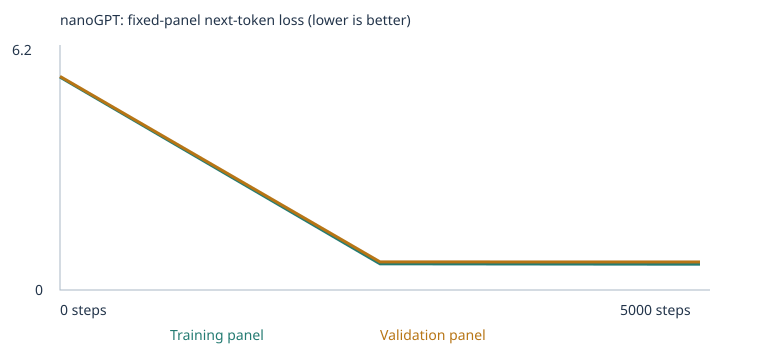

/Users/tongchienyi/Documents/01_Haas_MBA/02_Class/2nd Year/Agentic AI/class4-custom-llm/llm_runs/20260922T073639_742714Z.zip

Saved: llm_runs/20260922T073639_742714Z 
Results ZIP: /Users/tongchienyi/Documents/01_Haas_MBA/02_Class/2nd Year/Agentic AI/class4-custom-llm/llm_runs/20260922T073639_742714Z.zip


In [11]:
config = {"model":"nanoGPT", "upstream_commit":UPSTREAM_COMMIT, "tokenizer":"word", "corpus_source":corpus_source,
    "corpus_sha256":hashlib.sha256(raw_text.encode()).hexdigest(), "training_steps":TRAINING_STEPS,
    "learning_rate":LEARNING_RATE, "seed":SEED, "n_embd":N_EMBD, "n_head":N_HEAD, "n_layer":N_LAYER,
    "block_size":BLOCK_SIZE, "batch_size":BATCH_SIZE, "vocabulary_size":len(vocabulary),
    "parameters":sum(p.numel() for p in model.parameters()), "train_documents":len(train_docs),
    "validation_documents":len(val_docs), "validation_unknown_rate":unknown_rate, "training_unknown_rate":training_unknown_rate,
    "corpus_files":len(corpus_manifest["files"]), "corpus_mode":CORPUS,
    "evaluation_panel_size":{"train":len(eval_train),"validation":len(eval_val)},
    "evaluation_reduction":"mean over non-padding next-token panel targets",
    "language_eval_suite_sha256":final_language_summary["suite_sha256"],
    "reserved_eval_passages":eval_separation["excluded_passages"],
    "python":sys.version,"torch":str(torch.__version__),"device":DEVICE,"hardware":platform.platform()}
save_json("config.json",config)
save_json("training_summary.json",{"completed_steps":completed_steps,"elapsed_seconds":elapsed,"interrupted":interrupted})
save_json("checkpoint.json",{"format":"classroom-nanogpt-embeddings-v1","config":config,"vocabulary":vocabulary,
    "completed_steps":completed_steps,"weights":{"wte":model.transformer.wte.weight.detach().cpu().tolist()},
    "initial_embeddings":initial_embeddings.tolist(),"token_counts":[counts.get(t,0) for t in vocabulary]})
torch.save({"model":{k:v.detach().cpu() for k,v in model.state_dict().items()},"model_args":vars(model_config),
    "vocabulary":vocabulary,"completed_steps":completed_steps},run_dir/"model.pt")
with (run_dir/"training.csv").open("w",newline="") as file:
    writer = csv.DictWriter(file,fieldnames=["step","training_loss","validation_loss"])
    writer.writeheader()
    writer.writerows(history)
upper = max(row[key] for row in history for key in ["training_loss","validation_loss"])*1.1
def points(key):
    return " ".join(f"{60+row['step']/max(1,completed_steps)*640:.1f},{290-row[key]/upper*235:.1f}" for row in history)
svg = f'''<svg xmlns="http://www.w3.org/2000/svg" width="760" height="350" viewBox="0 0 760 350">
<rect width="760" height="350" fill="white"/><g font-family="sans-serif" font-size="14" fill="#22344a">
<text x="60" y="25">nanoGPT: fixed-panel next-token loss (lower is better)</text>
<path d="M60 45V290H710" fill="none" stroke="#aab8c6"/><text x="35" y="295">0</text>
<text x="12" y="55">{upper:.1f}</text><text x="60" y="315">0 steps</text><text x="620" y="315">{completed_steps} steps</text>
<polyline points="{points('training_loss')}" fill="none" stroke="#247b72" stroke-width="3"/>
<polyline points="{points('validation_loss')}" fill="none" stroke="#b77515" stroke-width="3"/>
<text x="170" y="340" fill="#247b72">Training panel</text><text x="380" y="340" fill="#b77515">Validation panel</text></g></svg>'''
(run_dir/"training_curves.svg").write_text(svg)
archive = shutil.make_archive(str(run_dir),"zip",run_dir)
try:
    from IPython.display import SVG, FileLink, display
    display(SVG(svg))
    display(FileLink(archive))
except ImportError:
    pass
print("Saved:",run_dir,"\nResults ZIP:",archive)

## 10. Chat with your trained model
Edit CHAT_PROMPT and rerun the next cell for each new message. Each message starts
fresh; this model continues text and is not instruction-trained. The cell uses the
model you just trained, saves every interaction, and refreshes the results ZIP.
A terminal alternative is: python chat.py --model path/to/model.pt
Include at least three real interactions and a screenshot or short recording.

In [12]:
CHAT_PROMPT = "diego did not choose a jacket . diego chose"
chat_file = run_dir/"chat_transcript.json"
chat_record = json.loads(chat_file.read_text()) if chat_file.exists() else {
    "model_sha256":model_hash(model), "completed_steps":completed_steps,
    "fresh_context_per_prompt":True, "temperature":0.8, "max_tokens":24, "turns":[]}
if chat_record["model_sha256"] != model_hash(model):
    raise ValueError("The model changed. Start a new run instead of mixing chat evidence.")
chat_seed = 2026 + len(chat_record["turns"])
reply = generate_reply(model, vocabulary, CHAT_PROMPT, seed=chat_seed)
print("You:", CHAT_PROMPT, "\nModel:", reply["response"] or "[empty response]")
if reply["unknown_prompt_words"]:
    print("Unknown words:", reply["unknown_prompt_words"])
if reply["prompt_truncated"]:
    print("Long prompt: only the most recent 48 tokens were used.")
chat_record["turns"].append({"prompt":CHAT_PROMPT, "seed":chat_seed, **reply})
save_json("chat_transcript.json",chat_record)
archive = shutil.make_archive(str(run_dir),"zip",run_dir)
print("Saved chat and refreshed ZIP:", archive)
try:
    display(FileLink(archive))
except NameError:
    pass

You: diego did not choose a jacket . diego chose 
Model: .
Unknown words: ['jacket']


Saved chat and refreshed ZIP: /Users/tongchienyi/Documents/01_Haas_MBA/02_Class/2nd Year/Agentic AI/class4-custom-llm/llm_runs/20260922T073639_742714Z.zip


/Users/tongchienyi/Documents/01_Haas_MBA/02_Class/2nd Year/Agentic AI/class4-custom-llm/llm_runs/20260922T073639_742714Z.zip

In [13]:
CHAT_PROMPT = "the kite is above the shelf . the shelf is"
chat_file = run_dir/"chat_transcript.json"
chat_record = json.loads(chat_file.read_text()) if chat_file.exists() else {
    "model_sha256":model_hash(model), "completed_steps":completed_steps,
    "fresh_context_per_prompt":True, "temperature":0.8, "max_tokens":24, "turns":[]}
if chat_record["model_sha256"] != model_hash(model):
    raise ValueError("The model changed. Start a new run instead of mixing chat evidence.")
chat_seed = 2026 + len(chat_record["turns"])
reply = generate_reply(model, vocabulary, CHAT_PROMPT, seed=chat_seed)
print("You:", CHAT_PROMPT, "\nModel:", reply["response"] or "[empty response]")
if reply["unknown_prompt_words"]:
    print("Unknown words:", reply["unknown_prompt_words"])
if reply["prompt_truncated"]:
    print("Long prompt: only the most recent 48 tokens were used.")
chat_record["turns"].append({"prompt":CHAT_PROMPT, "seed":chat_seed, **reply})
save_json("chat_transcript.json",chat_record)
archive = shutil.make_archive(str(run_dir),"zip",run_dir)
print("Saved chat and refreshed ZIP:", archive)
try:
    display(FileLink(archive))
except NameError:
    pass

You: the kite is above the shelf . the shelf is 
Model: .


Saved chat and refreshed ZIP: /Users/tongchienyi/Documents/01_Haas_MBA/02_Class/2nd Year/Agentic AI/class4-custom-llm/llm_runs/20260922T073639_742714Z.zip


/Users/tongchienyi/Documents/01_Haas_MBA/02_Class/2nd Year/Agentic AI/class4-custom-llm/llm_runs/20260922T073639_742714Z.zip

In [14]:
CHAT_PROMPT = "the weather today is"
chat_file = run_dir/"chat_transcript.json"
chat_record = json.loads(chat_file.read_text()) if chat_file.exists() else {
    "model_sha256":model_hash(model), "completed_steps":completed_steps,
    "fresh_context_per_prompt":True, "temperature":0.8, "max_tokens":24, "turns":[]}
if chat_record["model_sha256"] != model_hash(model):
    raise ValueError("The model changed. Start a new run instead of mixing chat evidence.")
chat_seed = 2026 + len(chat_record["turns"])
reply = generate_reply(model, vocabulary, CHAT_PROMPT, seed=chat_seed)
print("You:", CHAT_PROMPT, "\nModel:", reply["response"] or "[empty response]")
if reply["unknown_prompt_words"]:
    print("Unknown words:", reply["unknown_prompt_words"])
if reply["prompt_truncated"]:
    print("Long prompt: only the most recent 48 tokens were used.")
chat_record["turns"].append({"prompt":CHAT_PROMPT, "seed":chat_seed, **reply})
save_json("chat_transcript.json",chat_record)
archive = shutil.make_archive(str(run_dir),"zip",run_dir)
print("Saved chat and refreshed ZIP:", archive)
try:
    display(FileLink(archive))
except NameError:
    pass

You: the weather today is 
Model: over the team
Unknown words: ['weather']
Saved chat and refreshed ZIP: /Users/tongchienyi/Documents/01_Haas_MBA/02_Class/2nd Year/Agentic AI/class4-custom-llm/llm_runs/20260922T073639_742714Z.zip


/Users/tongchienyi/Documents/01_Haas_MBA/02_Class/2nd Year/Agentic AI/class4-custom-llm/llm_runs/20260922T073639_742714Z.zip

## 11. Explain in your own words
1. What can your corpus teach? What does this particular held-out split test?
2. Trace one word through token, ID and 64-number embedding.
3. Connect a prediction, loss, gradient and the saved parameter update.
4. Which neighbors changed? Why is 3D proximity imperfect?
5. What changed in samples and validation loss? What remains unconvincing?
6. Explain attention, temperature and one next experiment. More training is not
   automatically better; a synthetic corpus does not demonstrate general knowledge.
7. Which eval skills improved? Which lacked vocabulary or examples? Compare the
   starter run with your corpus-extension run using the same 48 tests.
8. Show actual chat interactions and explain one failure or limitation.
Save the executed notebook, evidence and README in your own public repository.
Submit its URL through the course portal. Keep both experiment results.

### Submission check
- Four complete 48-case result sets: starter untrained/trained and expanded untrained/trained.
- A four-row README comparison, category scores, coverage, and linked per-case outputs.
- At least two extension categories, new teaching data, and corpus-separation evidence.
- Actual free continuations, a concrete failure/limitation, and an explanation of the outcomes.
- Both executed notebooks, model evidence, launch instructions, and at least three real chat interactions.
Apply the 4/3/3 grading guidance near the top. No accuracy threshold or guaranteed improvement is required.